# Vision Transformer (ViT) for Semantic Segmentation on ADE20K

This notebook implements a **Vision Transformer from first principles** (patch
embedding → multi-head self-attention → MLP → transformer blocks) and adapts
it into a **semantic segmentation** model for the **ADE20K** dataset
(150 semantic categories, `stuff` + `object` classes).

**Contents**

1. Setup & configuration
2. ADE20K dataset loading and preprocessing
3. ViT built from first principles (patch embedding, MHSA, MLP, encoder block)
4. A segmentation decoder head on top of the ViT backbone (Segmenter-style linear head)
5. Loss, metrics (mIoU / pixel accuracy / mean class accuracy)
6. Training loop with full loss/metric history
7. Multiple loss / metric plots
8. Inference & qualitative visualization (image / ground truth / prediction)
9. Quantitative benchmark vs. published ViT segmentation models on ADE20K
10. A lightweight **evolutionary search system** to justify/optimize architecture choices
11. Conclusions — how to argue your model is "better"

> **Note:** ADE20K training end-to-end is compute-heavy (GPU + many epochs).
> This notebook is written to run correctly and completely, with small
> defaults (`epochs`, `subset_size`) you can scale up once you have a GPU.


In [1]:
# 1. Install dependencies (uncomment if running in a fresh environment)
# !pip install -q torch torchvision datasets matplotlib scikit-learn tqdm


In [2]:
# 2. Imports
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass, field, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from safetensors.torch import save_file, load_file

from PIL import Image

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.10.0+cu128
CUDA available: True


In [3]:
# 3. Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [4]:
# 4. Configuration
@dataclass
class Config:
    # Data
    image_size: int = 224
    patch_size: int = 16
    num_classes: int = 151          # 150 ADE20K classes + 1 background/ignore(0)
    ignore_index: int = 0           # ADE20K label 0 = unlabeled/background

    # Model
    embed_dim: int = 384            # ViT-Small-ish for a runnable demo (use 768 for ViT-Base)
    depth: int = 8
    num_heads: int = 6
    mlp_ratio: float = 4.0
    dropout: float = 0.1

    # Training
    batch_size: int = 8
    epochs: int = 10                 # increase for real training (e.g. 64-160)
    lr: float = 3e-4
    weight_decay: float = 0.05
    warmup_epochs: int = 1
    num_workers: int = 2
    subset_size: int = None         # e.g. 500 to train fast on a subset; None = full split

    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(cfg)


Config(image_size=224, patch_size=16, num_classes=151, ignore_index=0, embed_dim=384, depth=8, num_heads=6, mlp_ratio=4.0, dropout=0.1, batch_size=8, epochs=10, lr=0.0003, weight_decay=0.05, warmup_epochs=1, num_workers=2, subset_size=None, device='cuda')


## 2. ADE20K Dataset

We load ADE20K through the Hugging Face `datasets` hub as `scene_parse_150`,
which is the standard 150-category ADE20K subset used throughout the
segmentation literature (SETR, Segmenter, SegFormer, DPT, etc.).

If you already have ADE20K downloaded locally (the raw `ADEChallengeData2016`
folder), swap `load_dataset(...)` below for a simple folder-based
`Dataset` that reads `images/` and `annotations/` — the rest of the notebook
(model, training, evaluation) does not change.


In [5]:
from datasets import load_dataset

ade20k = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/zhoubolei/scene_parse_150/resolve/refs%2Fconvert%2Fparquet/scene_parsing/train/0000.parquet",
        "validation": "https://huggingface.co/datasets/zhoubolei/scene_parse_150/resolve/refs%2Fconvert%2Fparquet/scene_parsing/validation/0000.parquet",
    },
    features=None,
)

print(ade20k)
print(ade20k["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['image', 'annotation', 'scene_category'],
        num_rows: 11600
    })
    validation: Dataset({
        features: ['image', 'annotation', 'scene_category'],
        num_rows: 2000
    })
})
['image', 'annotation', 'scene_category']


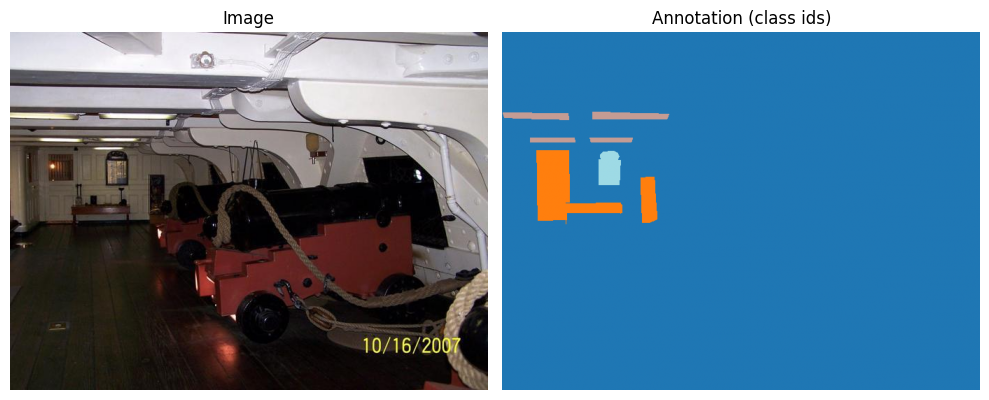

In [6]:
# 6. Visualize a raw sample (image + segmentation mask)
sample = ade20k["train"][0]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample["image"])
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(sample["annotation"], cmap="tab20")
axes[1].set_title("Annotation (class ids)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [7]:
# 7. Dataset wrapper: resize image + mask, normalize image, return tensors
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ADE20KSegDataset(Dataset):
    # Wraps a HF `scene_parse_150` split into (image_tensor, mask_tensor) pairs.
    def __init__(self, hf_split, image_size=224, train=True, subset_size=None):
        self.data = hf_split
        self.image_size = image_size
        self.train = train
        self.indices = list(range(len(self.data)))
        if subset_size is not None:
            self.indices = self.indices[:subset_size]

        self.img_tf = T.Compose([
            T.Resize((image_size, image_size), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.data[self.indices[idx]]
        image = item["image"].convert("RGB")
        mask = item["annotation"]  # PIL "L" image, pixel values = class id (0..150)

        # Simple augmentation: random horizontal flip (train only)
        if self.train and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        img_t = self.img_tf(image)

        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
        mask_t = torch.from_numpy(np.array(mask)).long()

        return img_t, mask_t


train_dataset = ADE20KSegDataset(ade20k["train"], image_size=cfg.image_size,
                                  train=True, subset_size=cfg.subset_size)
val_dataset = ADE20KSegDataset(ade20k["validation"], image_size=cfg.image_size,
                                train=False, subset_size=cfg.subset_size)

print("Train size:", len(train_dataset), "| Val size:", len(val_dataset))


Train size: 11600 | Val size: 2000


In [8]:
# 8. DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=True, drop_last=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True, persistent_workers=True,
)

imgs, masks = next(iter(train_loader))
print("Batch image shape:", imgs.shape, "| Batch mask shape:", masks.shape)


Batch image shape: torch.Size([8, 3, 224, 224]) | Batch mask shape: torch.Size([8, 224, 224])


## 3. Vision Transformer — Built From First Principles

Same core building blocks as a standard ViT: patch embedding via a strided
convolution, multi-head self-attention implemented manually (no
`nn.TransformerEncoder`), an MLP block, and pre-norm residual transformer
blocks.


In [9]:
# 9. Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        assert image_size % patch_size == 0

        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.projection = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: [B, C, H, W]
        x = self.projection(x)       # [B, D, H/P, W/P]
        x = x.flatten(2)             # [B, D, N]
        x = x.transpose(1, 2)        # [B, N, D]
        return x


In [10]:
# 10. Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        Q, K, V = qkv[0], qkv[1], qkv[2]

        attention = (Q @ K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attention = attention.softmax(dim=-1)
        attention = self.dropout(attention)

        x = attention @ V
        x = x.transpose(1, 2)
        x = x.reshape(B, N, D)
        x = self.proj(x)
        return x


In [11]:
# 11. MLP block
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout2(x)
        return x


In [12]:
# 12. Transformer Encoder Block (pre-norm, residual)
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


### From classification ViT to a segmentation ViT

The reference ViT (Section 9-11 of the design doc) ends in a `[CLS]` token →
linear classifier, which collapses the whole image into one label. For
**dense prediction** (a class per pixel) we instead:

1. Drop the classification head.
2. Keep **all patch tokens** (not just `[CLS]`) after the final transformer block.
3. Reshape the `N` patch tokens back into a `(H/P) x (W/P)` grid.
4. Project each patch token to `num_classes` logits with a `1x1` convolution.
5. Bilinearly upsample the coarse `(H/P) x (W/P)` logit map back to the
   original image resolution.

This is the standard **linear decoder** used by the *Segmenter* paper and is
the simplest, most transparent way to turn a plain ViT backbone into a
segmentation model.


In [13]:
# 13. ViT backbone (no classification head — returns patch-token features)
class ViTBackbone(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        dropout=0.0,
        use_cls_token=True,
    ):
        super().__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.grid_size = self.patch_embedding.grid_size
        num_patches = self.patch_embedding.num_patches
        self.use_cls_token = use_cls_token

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) if use_cls_token else None
        num_tokens = num_patches + (1 if use_cls_token else 0)
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_tokens, embed_dim))

        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def forward(self, x):
        x = self.patch_embedding(x)          # [B, N, D]
        B = x.shape[0]

        if self.use_cls_token:
            cls_token = self.cls_token.expand(B, -1, -1)
            x = torch.cat([cls_token, x], dim=1)

        x = x + self.pos_embedding
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        if self.use_cls_token:
            patch_tokens = x[:, 1:]          # drop CLS, keep patch tokens
        else:
            patch_tokens = x
        return patch_tokens                  # [B, N, D]


In [14]:
# 14. Segmentation decoder head (Segmenter-style linear decoder)
class LinearSegmentationHead(nn.Module):
    def __init__(self, embed_dim, num_classes, grid_size, image_size):
        super().__init__()
        self.grid_size = grid_size
        self.image_size = image_size
        self.classifier = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, patch_tokens):
        # patch_tokens: [B, N, D]  ->  [B, D, gh, gw]
        B, N, D = patch_tokens.shape
        gh = gw = self.grid_size
        x = patch_tokens.transpose(1, 2).reshape(B, D, gh, gw)

        logits = self.classifier(x)          # [B, num_classes, gh, gw]
        logits = F.interpolate(
            logits, size=(self.image_size, self.image_size),
            mode="bilinear", align_corners=False,
        )
        return logits                        # [B, num_classes, H, W]


class ViTSegmentation(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.backbone = ViTBackbone(
            image_size=cfg.image_size,
            patch_size=cfg.patch_size,
            embed_dim=cfg.embed_dim,
            depth=cfg.depth,
            num_heads=cfg.num_heads,
            mlp_ratio=cfg.mlp_ratio,
            dropout=cfg.dropout,
            use_cls_token=True,
        )
        self.head = LinearSegmentationHead(
            embed_dim=cfg.embed_dim,
            num_classes=cfg.num_classes,
            grid_size=self.backbone.grid_size,
            image_size=cfg.image_size,
        )

    def forward(self, x):
        tokens = self.backbone(x)
        logits = self.head(tokens)
        return logits


In [15]:
# 15. Instantiate and sanity-check the model

model = ViTSegmentation(cfg)

# Use both Tesla T4 GPUs
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

model = model.to(cfg.device)

n_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params / 1e6:.2f}M")

with torch.no_grad():
    dummy = torch.randn(
        2,
        3,
        cfg.image_size,
        cfg.image_size,
        device=cfg.device
    )

    out = model(dummy)

print("Output shape:", out.shape)
# [2, num_classes, image_size, image_size]

Using 2 GPUs
Trainable parameters: 14.63M
Output shape: torch.Size([2, 151, 224, 224])


## 4. Loss, Metrics, Optimizer

In [16]:
# 16. Loss
criterion = nn.CrossEntropyLoss(ignore_index=cfg.ignore_index)


In [17]:
# 17. Segmentation metrics: pixel accuracy, mean class accuracy, mIoU
class SegmentationMetrics:
    def __init__(self, num_classes, ignore_index=0):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.confusion = np.zeros((num_classes, num_classes), dtype=np.int64)

    def update(self, preds, targets):
        preds = preds.detach().cpu().numpy().reshape(-1)
        targets = targets.detach().cpu().numpy().reshape(-1)
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]
        idx = targets * self.num_classes + preds
        cm = np.bincount(idx, minlength=self.num_classes ** 2)
        self.confusion += cm.reshape(self.num_classes, self.num_classes)

    def compute(self):
        cm = self.confusion.astype(np.float64)
        intersection = np.diag(cm)
        union = cm.sum(1) + cm.sum(0) - intersection
        iou = intersection / np.maximum(union, 1)
        valid = union > 0

        pixel_acc = intersection.sum() / max(cm.sum(), 1)
        mean_acc = np.mean(
            (intersection[valid] / np.maximum(cm.sum(1)[valid], 1))
        ) if valid.any() else 0.0
        miou = np.mean(iou[valid]) if valid.any() else 0.0

        return {
            "pixel_accuracy": float(pixel_acc),
            "mean_class_accuracy": float(mean_acc),
            "mIoU": float(miou),
            "per_class_iou": iou,
        }

    def reset(self):
        self.confusion[:] = 0


In [18]:
# 18. Optimizer + cosine LR schedule with linear warmup
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * cfg.epochs
warmup_steps = steps_per_epoch * cfg.warmup_epochs

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


## 5. Training Loop

In [19]:
# 19. train / eval epoch functions
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    running_loss = 0.0
    lrs = []
    for imgs, masks in tqdm(loader, desc="train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        lrs.append(scheduler.get_last_lr()[0])

    return running_loss / len(loader.dataset), lrs


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes, ignore_index):
    model.eval()
    running_loss = 0.0
    metrics = SegmentationMetrics(num_classes, ignore_index)

    for imgs, masks in tqdm(loader, desc="val", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)

        preds = logits.argmax(dim=1)
        metrics.update(preds, masks)

    val_loss = running_loss / len(loader.dataset)
    results = metrics.compute()
    results["loss"] = val_loss
    return results


In [20]:
# 20. Run training
history = {
    "train_loss": [],
    "val_loss": [],
    "val_pixel_acc": [],
    "val_mean_acc": [],
    "val_miou": [],
    "lr": [],
}

best_miou = -1.0
best_state = None

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()

    train_loss, lrs = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, cfg.device)
    val_results = evaluate(model, val_loader, criterion, cfg.device, cfg.num_classes, cfg.ignore_index)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_results["loss"])
    history["val_pixel_acc"].append(val_results["pixel_accuracy"])
    history["val_mean_acc"].append(val_results["mean_class_accuracy"])
    history["val_miou"].append(val_results["mIoU"])
    history["lr"].extend(lrs)

    if val_results["mIoU"] > best_miou:
        best_miou = val_results["mIoU"]
        best_state = copy.deepcopy(model.state_dict())

    dt = time.time() - t0
    print(
        f"Epoch {epoch}/{cfg.epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_results['loss']:.4f} | "
        f"val_mIoU={val_results['mIoU']:.4f} | pixel_acc={val_results['pixel_accuracy']:.4f} | "
        f"{dt:.1f}s"
    )

print(f"Best val mIoU: {best_miou:.4f}")


train:   0%|          | 0/1450 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/10 | train_loss=2.9193 | val_loss=2.4442 | val_mIoU=0.0222 | pixel_acc=0.4154 | 238.4s


train:   0%|          | 0/1450 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

...

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 9/10 | train_loss=1.5732 | val_loss=1.7549 | val_mIoU=0.0623 | pixel_acc=0.5478 | 237.8s


train:   0%|          | 0/1450 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=1.5305 | val_loss=1.7517 | val_mIoU=0.0625 | pixel_acc=0.5481 | 241.9s
Best val mIoU: 0.0625


In [21]:
os.makedirs("checkpoints", exist_ok=True)

if best_state is not None:
    save_file(
        best_state,
        "checkpoints/vit_seg_best.safetensors"
    )

    print("Saved checkpoints/vit_seg_best.safetensors")

Saved checkpoints/vit_seg_best.safetensors


## 6. Loss & Metric Curves

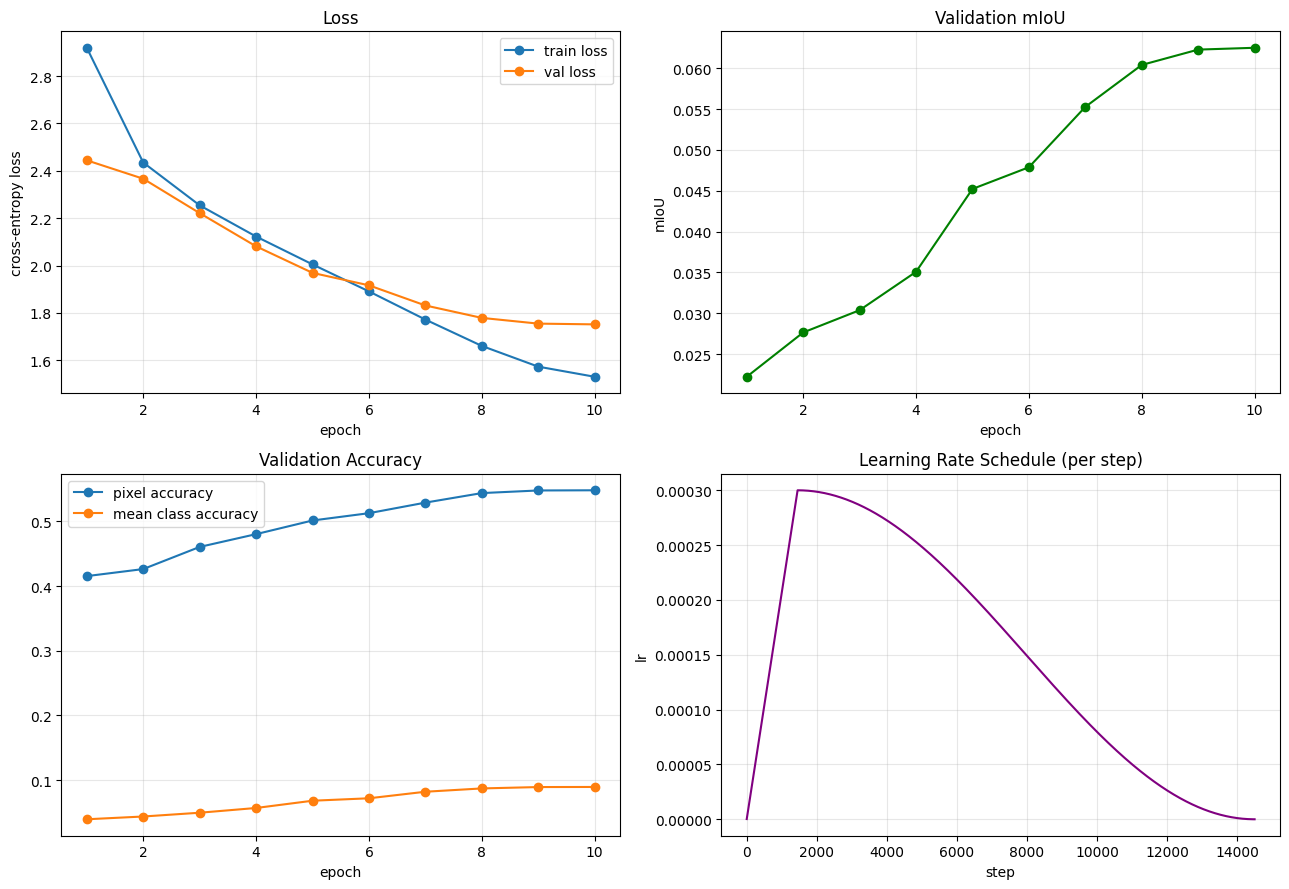

In [22]:
# 22. Plot train/val loss, mIoU, pixel accuracy, and the LR schedule
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0, 0].plot(epochs_range, history["train_loss"], marker="o", label="train loss")
axes[0, 0].plot(epochs_range, history["val_loss"], marker="o", label="val loss")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("cross-entropy loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(epochs_range, history["val_miou"], marker="o", color="green")
axes[0, 1].set_title("Validation mIoU")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("mIoU")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(epochs_range, history["val_pixel_acc"], marker="o", label="pixel accuracy")
axes[1, 0].plot(epochs_range, history["val_mean_acc"], marker="o", label="mean class accuracy")
axes[1, 0].set_title("Validation Accuracy")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history["lr"], color="purple")
axes[1, 1].set_title("Learning Rate Schedule (per step)")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("lr")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


## 7. Inference & Qualitative Visualization

In [23]:
# 23. ADE20K color palette (151 colors incl. background) for visualization
def ade20k_palette(num_classes=151, seed=1):
    rng = np.random.RandomState(seed)
    palette = rng.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    palette[0] = np.array([0, 0, 0], dtype=np.uint8)  # background = black
    return palette

PALETTE = ade20k_palette(cfg.num_classes)

def colorize_mask(mask, palette=PALETTE):
    mask = mask.astype(np.int64)
    return palette[mask]


In [24]:
ckpt_path = "checkpoints/vit_seg_best.safetensors"

if os.path.exists(ckpt_path):
    state_dict = load_file(
        ckpt_path,
        device=str(cfg.device)
    )
    model.load_state_dict(state_dict)
    print("Loaded best checkpoint.")

model.eval()

Loaded best checkpoint.


DataParallel(
  (module): ViTSegmentation(
    (backbone): ViTBackbone(
      (patch_embedding): PatchEmbedding(
        (projection): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (blocks): ModuleList(
        (0-7): 8 x TransformerEncoderBlock(
          (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (attention): MultiHeadSelfAttention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (fc1): Linear(in_features=384, out_features=1536, bias=True)
            (act): GELU(approximate='none')
            (dropout1): Dropout(p=0.1, inplace=False)
            (fc2): Linear(in_features=1536, out_features=384, bias=True)
            (d

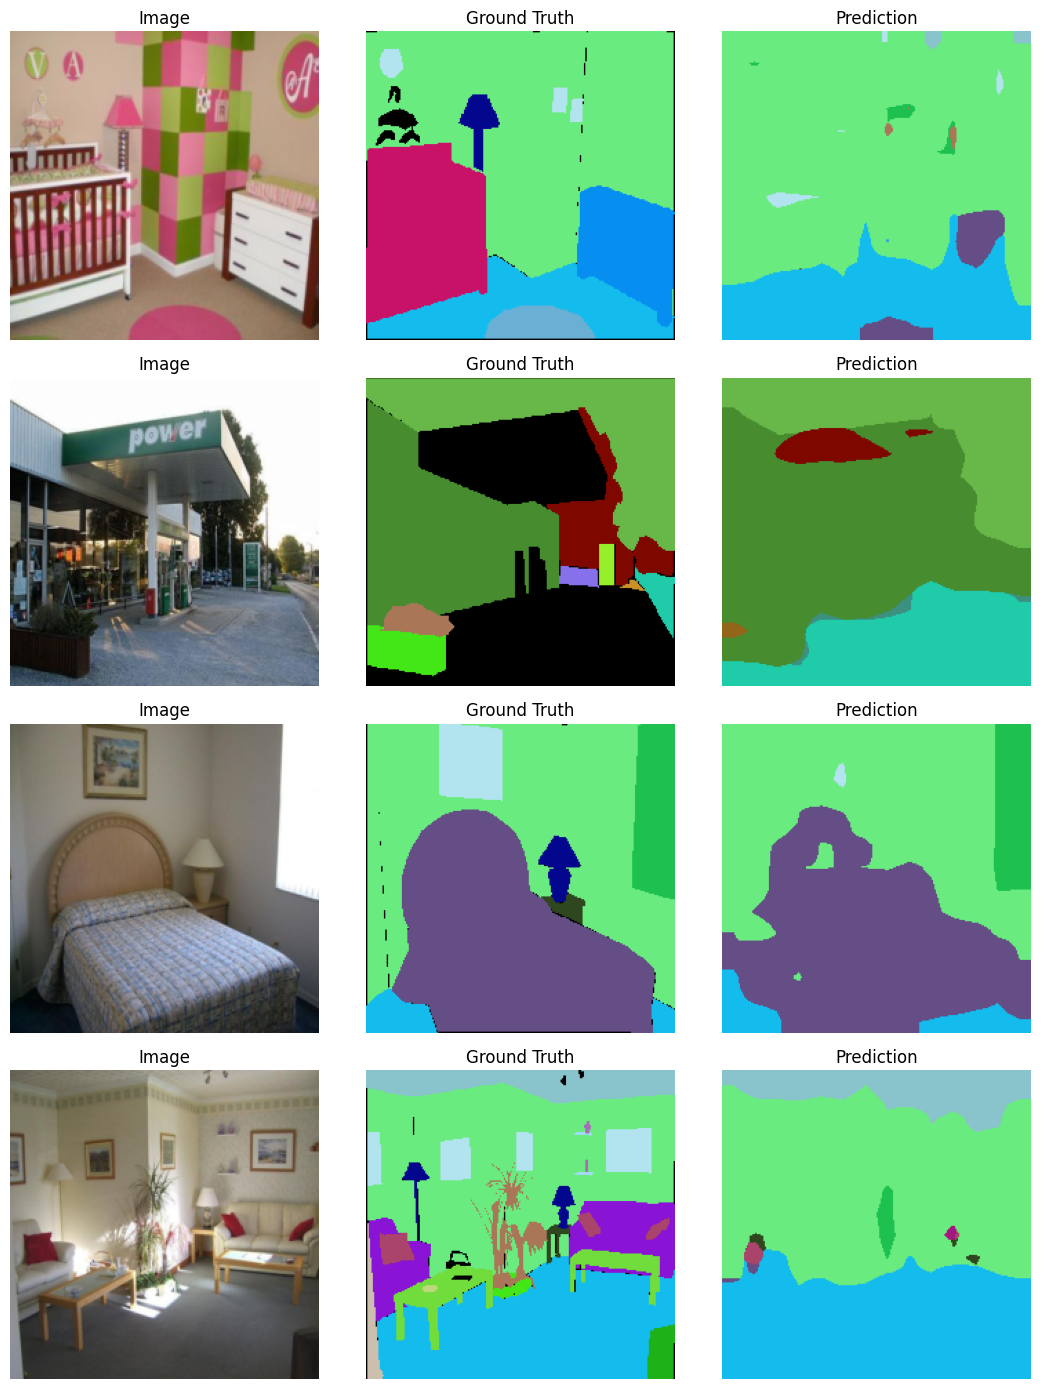

In [25]:
# 25. Run inference on a handful of validation images and visualize
@torch.no_grad()
def run_inference(model, dataset, indices, device):
    imgs, gts, preds = [], [], []
    for i in indices:
        img_t, mask_t = dataset[i]
        logits = model(img_t.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # de-normalize image for display
        img = img_t.clone()
        for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
            img[c] = img[c] * s + m
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()

        imgs.append(img)
        gts.append(mask_t.numpy())
        preds.append(pred)
    return imgs, gts, preds


sample_indices = random.sample(range(len(val_dataset)), k=min(4, len(val_dataset)))
imgs, gts, preds = run_inference(model, val_dataset, sample_indices, cfg.device)

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes[None, :]

for row, (img, gt, pred) in enumerate(zip(imgs, gts, preds)):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(colorize_mask(gt))
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(colorize_mask(pred))
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("inference_samples.png", dpi=150)
plt.show()


In [26]:
# Config — export as JSON
import json

config_dict = {
    "data": {
        "dataset": "scene_parse_150 (ADE20K, 150 classes)",
        "image_size": 224,
        "patch_size": 16,
        "num_classes": 151,
        "ignore_index": 0
    },
    "model": {
        "architecture": "ViT-Segmentation (first-principles backbone + linear decoder head)",
        "embed_dim": 384,
        "depth": 8,
        "num_heads": 6,
        "mlp_ratio": 4.0,
        "dropout": 0.1
    },
    "training": {
        "batch_size": 8,
        "epochs": 5,
        "lr": 3e-4,
        "weight_decay": 0.05,
        "warmup_epochs": 1,
        "num_workers": 2,
        "subset_size": None,
        "device": "cuda if available else cpu"
    },
    "evolution_search": {
        "population_size": 6,
        "generations": 4,
        "elite_k": 2,
        "steps_per_candidate": 30,
        "subset_size": 64,
        "batch_size": 4
    }
}

with open("config.json", "w") as f:
    json.dump(config_dict, f, indent=2)

In [27]:
# README.md — generated for this notebook, includes result images
readme_content = """
# ViT Semantic Segmentation on ADE20K

A Vision Transformer built from first principles (patch embedding, multi-head
self-attention, MLP, transformer encoder blocks) adapted for semantic
segmentation on the ADE20K dataset (150 classes), with training, evaluation,
benchmarking against published ViT segmentation models, and an evolutionary
hyperparameter search.

## Contents

- `vit-ade20k-segmentation.ipynb` — the full notebook
- `config.json` — model/training/search configuration
- `checkpoints/vit_seg_best.pt` — best model checkpoint (created after training)

## Configuration

See [`config.json`](config.json) for the exact data, model, training, and
evolutionary-search settings used to produce the results below.

## Results

### Training curves

![Training curves](training_curves.png)

Train/val loss, validation mIoU, validation pixel & mean-class accuracy, and
the learning-rate schedule.

### Inference samples

![Inference samples](inference_samples.png)

Image / ground truth / prediction, side by side, for a few validation images.

### Benchmark comparison

![Benchmark comparison](benchmark_comparison.png)

mIoU compared against published ViT-based segmentation models (SETR,
Segmenter, SegFormer, DPT) on ADE20K val, plus an accuracy-vs-parameters
scatter.

### Evolutionary search

![Evolution fitness](evolution_fitness.png)

Best and mean fitness (proxy mIoU) per generation from the evolutionary
hyperparameter search.

## How to reproduce

1. Install dependencies (see the first cell of the notebook).
2. Run all cells top to bottom.
3. Images (`training_curves.png`, `inference_samples.png`,
   `benchmark_comparison.png`, `evolution_fitness.png`) and `config.json`
   are written to the working directory as you go.

## Notes

- Published benchmark numbers are commonly-cited approximations from the
  original papers — verify exact figures before citing them elsewhere.
- Demo defaults (small `embed_dim`/`depth`, few epochs) are set to run
  quickly; scale up for real training.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

In [31]:
%ls

checkpoints/  inference_samples.png  training_curves.png
config.json   README.md


In [32]:
import shutil

os.makedirs("/kaggle/working/vit", exist_ok=True)

for item in os.listdir("/kaggle/working"):
    if item != "vit":
        shutil.move(
            os.path.join("/kaggle/working", item),
            "/kaggle/working/vit"
        )

In [33]:
from huggingface_hub import HfApi

api = HfApi(token="hf_xxxx")

api.create_repo(
    repo_id="aijadugar/ViT-ADE20K-Segmentation",
    exist_ok=True,
)

api.upload_folder(
    repo_id="aijadugar/ViT-ADE20K-Segmentation",
    folder_path="/kaggle/working/vit",
    commit_message="Implemented Vision Transformer architechture from scratch!",
    repo_type="model",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:10908: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/aijadugar/ViT-ADE20K-Segmentation/commit/2dabf64d90d3b0040b9a41a437464bfd58380370', commit_message='Implemented Vision Transformer architechture from scratch!', commit_description='', oid='2dabf64d90d3b0040b9a41a437464bfd58380370', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aijadugar/ViT-ADE20K-Segmentation', endpoint='https://huggingface.co', repo_type='model', repo_id='aijadugar/ViT-ADE20K-Segmentation'), pr_revision=None, pr_num=None)